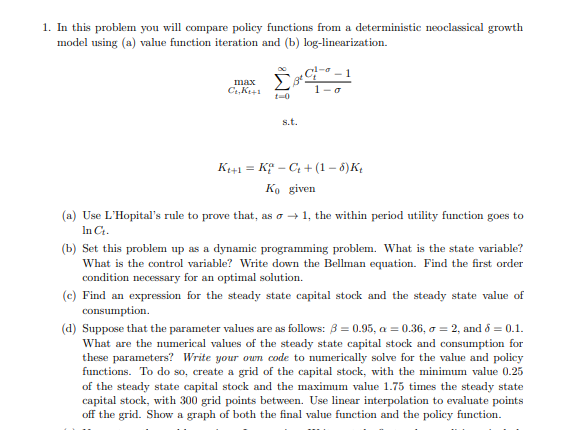

I am solving the part d of the problem which is the standard neoclassical model 

In [1]:
#Value functoion iterations

import numpy as np
import matplotlib.pyplot as plt


In [2]:
beta = 0.95
alpha = 0.36
sigma = 2
delta = 0.1

In [3]:
#Utility Function
def utility(c):
    if sigma == 1:
        return np.log(c)
    else:
        return  (c**(1-sigma)-1)/(1-sigma)


In [4]:
# ==========================================================
# Steady State
# ==========================================================
k_ss = ((1/beta - (1-delta))/alpha)**(1/(alpha-1))
c_ss = k_ss**alpha - delta*k_ss

In [5]:
print("Steady State Capital =", k_ss)
print("Steady State Consumption =", c_ss)

Steady State Capital = 3.8218909152179132
Steady State Consumption = 1.2382032555735218


In [6]:
#Grid 
Nk = 300

k_min = 0.25*k_ss
k_max = 1.75*k_ss

k_grid = np.linspace(k_min,k_max,Nk)

In [7]:
# ==========================================================
# Initial Guess
# ==========================================================

V = np.zeros(Nk)
policy = np.zeros(Nk)

tol = 1e-6
max_iter = 1000


In [8]:
for iteration in range(max_iter):

    V_new = np.zeros_like(V)

    policy_new = np.zeros_like(policy)

    for i,k in enumerate(k_grid):

        value_max = -1e10

        best_kprime = k_grid[0]

        # Candidate next-period capital
        for kp in k_grid:

            # Consumption implied by budget constraint
            c = k**alpha + (1-delta)*k - kp

            if c <= 0:
                continue

            # Continuation value using interpolation
            continuation = np.interp(kp,k_grid,V)

            value = utility(c) + beta*continuation

            if value > value_max:

                value_max = value
                best_kprime = kp

        V_new[i] = value_max
        policy_new[i] = best_kprime

    diff = np.max(np.abs(V_new-V))

    print(f"Iteration {iteration:3d}   Error = {diff:.8f}")

    V = V_new.copy()
    policy = policy_new.copy()

    if diff < tol:
        print("Converged!")
        
        break

Iteration   0   Error = 0.85807655
Iteration   1   Error = 0.62125784
Iteration   2   Error = 0.47303094
Iteration   3   Error = 0.37380510
Iteration   4   Error = 0.30400552
Iteration   5   Error = 0.25293134
Iteration   6   Error = 0.21438929
Iteration   7   Error = 0.18446158
Iteration   8   Error = 0.16074737
Iteration   9   Error = 0.14156001
Iteration  10   Error = 0.12577240
Iteration  11   Error = 0.11257472
Iteration  12   Error = 0.10142242
Iteration  13   Error = 0.09197202
Iteration  14   Error = 0.08370556
Iteration  15   Error = 0.07657032
Iteration  16   Error = 0.07025597
Iteration  17   Error = 0.06471276
Iteration  18   Error = 0.05982342
Iteration  19   Error = 0.05533975
Iteration  20   Error = 0.05139931
Iteration  21   Error = 0.04790039
Iteration  22   Error = 0.04448545
Iteration  23   Error = 0.04161100
Iteration  24   Error = 0.03896161
Iteration  25   Error = 0.03648578
Iteration  26   Error = 0.03411629
Iteration  27   Error = 0.03207651
Iteration  28   Erro

In [9]:
# ==========================================================
# Policy Consumption
# ==========================================================

consumption_policy = (
    k_grid**alpha
    +(1-delta)*k_grid
    -policy
)

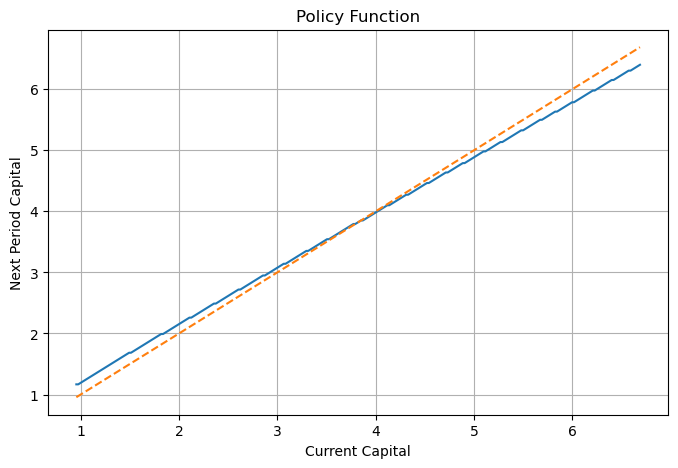

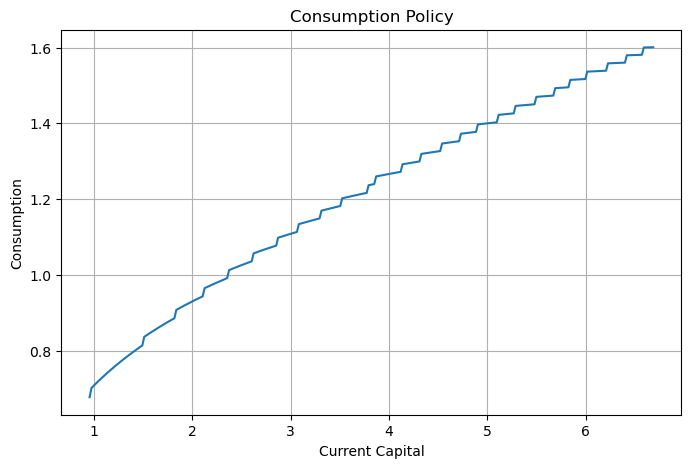

In [10]:
# ==========================================================
# Policy Consumption
# ==========================================================

consumption_policy = (
    k_grid**alpha
    +(1-delta)*k_grid
    -policy
)

plt.figure(figsize=(8,5))
plt.plot(k_grid,policy)
plt.plot(k_grid,k_grid,'--')
plt.xlabel("Current Capital")
plt.ylabel("Next Period Capital")
plt.title("Policy Function")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(k_grid,consumption_policy)
plt.xlabel("Current Capital")
plt.ylabel("Consumption")
plt.title("Consumption Policy")
plt.grid()
plt.show()